/tmp/ipykernel_2812037/2889091681.py:119: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


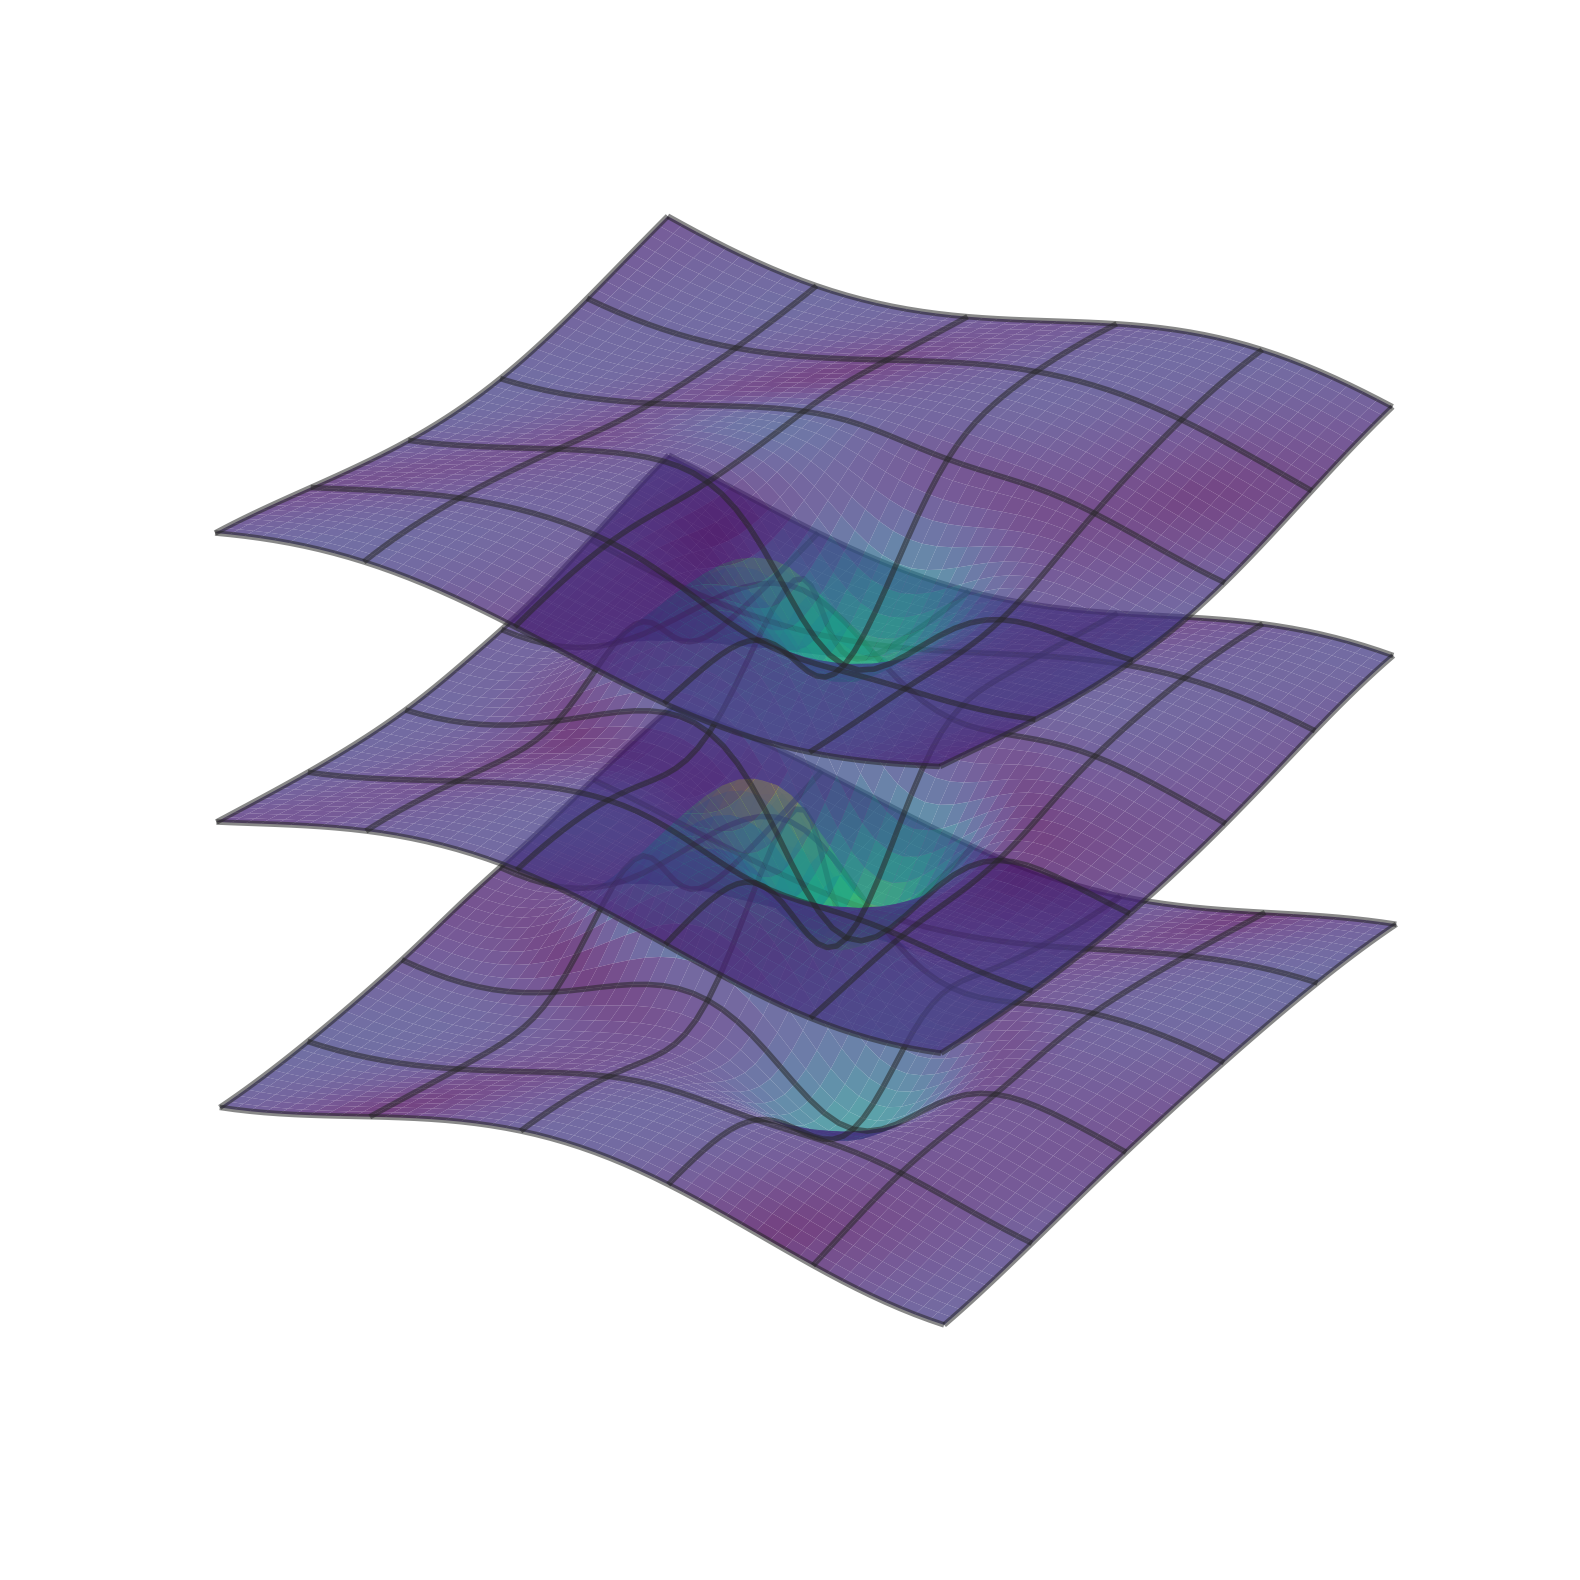

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

# =========================================================
# 1. Smooth motion-warp field
# =========================================================
def smooth_motion_warp(X, Y, phase=0.0):
    """
    Generate a smooth warp field (U, V, W) on a plane.
    X, Y : meshgrid
    phase: controls the motion state, allowing 3 planes to differ smoothly
    """

    G1 = np.exp(-(((X + 1.2) / 1.4) ** 2 + ((Y - 0.4) / 0.9) ** 2))
    G2 = np.exp(-(((X - 0.9) / 1.1) ** 2 + ((Y + 0.8) / 1.2) ** 2))

    wave = np.sin(0.7 * X - 0.45 * Y + phase)

    U = (
        0.22 * G1 * np.cos(phase)
        - 0.16 * G2 * np.sin(phase + 0.4)
        + 0.05 * np.sin(0.8 * Y + phase)
    )

    V = (
        0.18 * G1 * np.sin(phase + 0.8)
        + 0.14 * G2 * np.cos(phase)
        + 0.05 * np.cos(0.75 * X - 0.3 * phase)
    )

    W = (
        0.65 * G1 * np.cos(phase)
        - 0.55 * G2 * np.sin(phase + 0.6)
        + 0.10 * wave
    )

    return U, V, W


# =========================================================
# 2. Generate warped planes
# =========================================================
def generate_planes(
    n_planes=3,
    grid_n=90,
    xlim=(-4, 4),
    ylim=(-4, 4),
    plane_gap=1.4,   # <<< 这里控制平面之间的距离
):
    """
    Generate multiple warped planes.

    Parameters
    ----------
    plane_gap : float
        Distance between neighboring planes.
        Smaller -> planes are closer.
        Larger  -> planes are farther apart.
    """
    x = np.linspace(xlim[0], xlim[1], grid_n)
    y = np.linspace(ylim[0], ylim[1], grid_n)
    X, Y = np.meshgrid(x, y)

    planes = []
    for i in range(n_planes):
        phase = i * 0.8
        z0 = i * plane_gap

        U, V, W = smooth_motion_warp(X, Y, phase=phase)

        Xw = X + U
        Yw = Y + V
        Zw = z0 + W

        mag = np.sqrt(U**2 + V**2 + W**2)

        planes.append({
            "X": Xw,
            "Y": Yw,
            "Z": Zw,
            "mag": mag,
            "phase": phase,
            "z0": z0
        })

    return planes


# =========================================================
# 3. Plot
# =========================================================
def plot_warped_planes(
    planes,
    elev=28,
    azim=-58,
    cmap_name="viridis",
    surface_alpha=0.72,
    wire_color=(0.15, 0.15, 0.15, 0.55),
    show_colorbar=True,
    colorbar_ticks=False,   # <<< 是否显示刻度数字
    save_prefix="warped_planes"
):
    """
    Plot the warped planes in 3D and save to file.
    """

    fig = plt.figure(figsize=(10, 8), dpi=200)
    ax = fig.add_subplot(111, projection="3d")

    try:
        ax.set_proj_type("ortho")
    except Exception:
        pass

    all_mag = np.concatenate([p["mag"].ravel() for p in planes])
    norm = Normalize(vmin=all_mag.min(), vmax=all_mag.max())
    cmap = cm.get_cmap(cmap_name)

    for p in planes:
        X, Y, Z, mag = p["X"], p["Y"], p["Z"], p["mag"]
        facecolors = cmap(norm(mag))

        ax.plot_surface(
            X, Y, Z,
            facecolors=facecolors,
            rstride=1,
            cstride=1,
            linewidth=0,
            antialiased=True,
            shade=False,
            alpha=surface_alpha
        )

        ax.plot_wireframe(
            X, Y, Z,
            rstride=10,
            cstride=10,
            color=wire_color,
            linewidth=2
        )

    # View / layout
    ax.view_init(elev=elev, azim=azim)
    ax.set_box_aspect((1, 1, 0.75))

    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_zticks([])

    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_zlabel("")

    try:
        ax.xaxis.pane.fill = False
        ax.yaxis.pane.fill = False
        ax.zaxis.pane.fill = False

        ax.xaxis.pane.set_edgecolor((1, 1, 1, 0))
        ax.yaxis.pane.set_edgecolor((1, 1, 1, 0))
        ax.zaxis.pane.set_edgecolor((1, 1, 1, 0))
    except Exception:
        pass

    ax.grid(False)

    try:
        ax.xaxis.line.set_color((1, 1, 1, 0))
        ax.yaxis.line.set_color((1, 1, 1, 0))
        ax.zaxis.line.set_color((1, 1, 1, 0))
    except Exception:
        pass

    # -----------------------------------------------------
    # Colorbar: only keep the color strip itself
    # -----------------------------------------------------
    if show_colorbar:
        mappable = cm.ScalarMappable(norm=norm, cmap=cmap)
        mappable.set_array([])
        cbar = plt.colorbar(mappable, ax=ax, shrink=0.72, pad=0.04)

        # 不显示标题
        cbar.set_label("")

        if not colorbar_ticks:
            # 不显示刻度和数字，只保留色条本身
            cbar.set_ticks([])
            cbar.ax.tick_params(length=0)
        else:
            # 如果你只想隐藏标题，但保留刻度，可以把 colorbar_ticks=True
            pass

        # 让 colorbar 外观更简洁
        cbar.outline.set_linewidth(0.6)

    plt.tight_layout()

    plt.savefig(f"{save_prefix}.png", dpi=300, bbox_inches="tight", transparent=True)
    plt.savefig(f"{save_prefix}.pdf", bbox_inches="tight", transparent=True)
    plt.savefig(f"{save_prefix}.svg", bbox_inches="tight", transparent=True)

    plt.show()


# =========================================================
# 4. Main
# =========================================================
if __name__ == "__main__":
    planes = generate_planes(
        n_planes=3,
        grid_n=50,
        xlim=(-4, 4),
        ylim=(-4, 4),
        plane_gap=0.8,   # <<< 改这里：值越小，三个平面越近
    )

    plot_warped_planes(
        planes,
        elev=28,
        azim=-58,
        cmap_name="viridis",
        surface_alpha=0.75,
        show_colorbar=False,
        colorbar_ticks=False,   # <<< False = 只显示色条，不显示字
        save_prefix="three_smooth_warped_planes_close"
    )